In [1]:

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
# Loads the training and validation CSV files and names the target column that marks the income category.
train = pd.read_csv('project_adult.csv')
test = pd.read_csv('project_validation_inputs.csv')
target_col = 'income'

In [3]:
# Builds a preprocessing helper that cleans the dataset, encodes the categories, splits features from the target, and scales numeric columns.
def preprocess_data(df, target_col=None, le_dict=None, scaler=None):
    # Replaces missing numeric entries with the column median and categorical entries with the most common value.
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

    # Fits label encoders during training and reuses them later so category mappings stay consistent.
    if le_dict is None:
        le_dict = {}
        for col in df.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            le_dict[col] = le
    else:
        for col in df.select_dtypes(include=['object']).columns:
            if col in le_dict:
                df[col] = le_dict[col].transform(df[col])
            else:
                raise ValueError(f"Unexpected categorical column: {col}")

    # Separates the target column when it exists so the model sees inputs and labels separately.
    if target_col and target_col in df.columns:
        X = df.drop(columns=[target_col], axis=1)
        y = df[[target_col]]
    else:
        X = df.copy()
        y = None

    # Applies standard scaling to numeric columns, fitting during training and reusing the scaler afterwards.
    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
    if scaler is None:
        scaler = StandardScaler()
        X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    else:
        X[numeric_cols] = scaler.transform(X[numeric_cols])

    return X, y, le_dict, scaler


In [4]:
# Runs the preprocessing on training data first, then applies the stored encoders and scaler to the validation set so both share the same mappings.
X_train, y_train, le_dict, scaler = preprocess_data(train, target_col=target_col)
X_test, y_test, _, _ = preprocess_data(test, target_col=target_col, le_dict=le_dict, scaler=scaler)


In [5]:
# Standardizes every training feature using the dataset mean and standard deviation so each input dimension is on a similar scale.
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [6]:
# Converts the cleaned arrays into PyTorch tensors so the model can read floating-point features and categorical labels.
X_train_norm = torch.from_numpy(X_train_norm.values).float()
y_train = torch.from_numpy(y_train.values)

In [7]:
# Bundles feature and label tensors into a single dataset object that supports mini-batch sampling.
train_ds = TensorDataset(X_train_norm, y_train)

In [8]:
# Fixes the random seed for repeatable runs, defines a small batch size, and wraps the dataset in a shuffled DataLoader.
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [9]:
# Defines a two-layer MLP where a sigmoid hidden layer feeds into a softmax output that scores the income categories.
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)
        return x

In [10]:
# Reads the input dimension from the processed data, chooses a 16-unit hidden layer, and keeps three output nodes for the income groups.
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3

model = Model(input_size, hidden_size, output_size)

In [11]:

loss_fn = nn.CrossEntropyLoss()

In [12]:
# Configures the Adam optimizer with a 0.001 learning rate so gradients update the model weights smoothly
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
# Runs 100 training epochs, updates the model with each mini-batch, and records loss plus accuracy for later plots.
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        y_batch = y_batch.squeeze()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()

    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

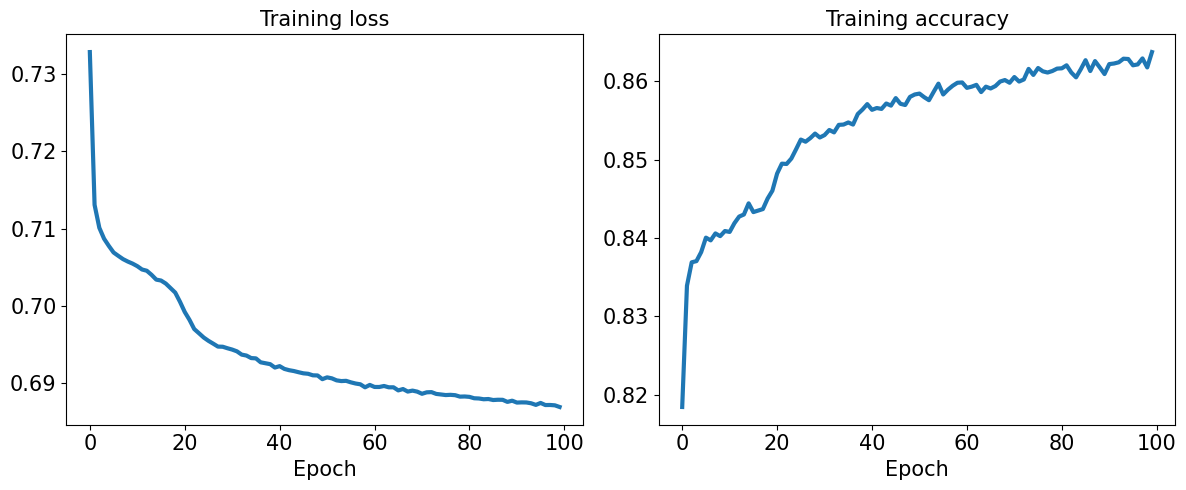

In [14]:
# Draws loss and accuracy curves for the first training run to check whether the network is learning smoothly.
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
plt.show()

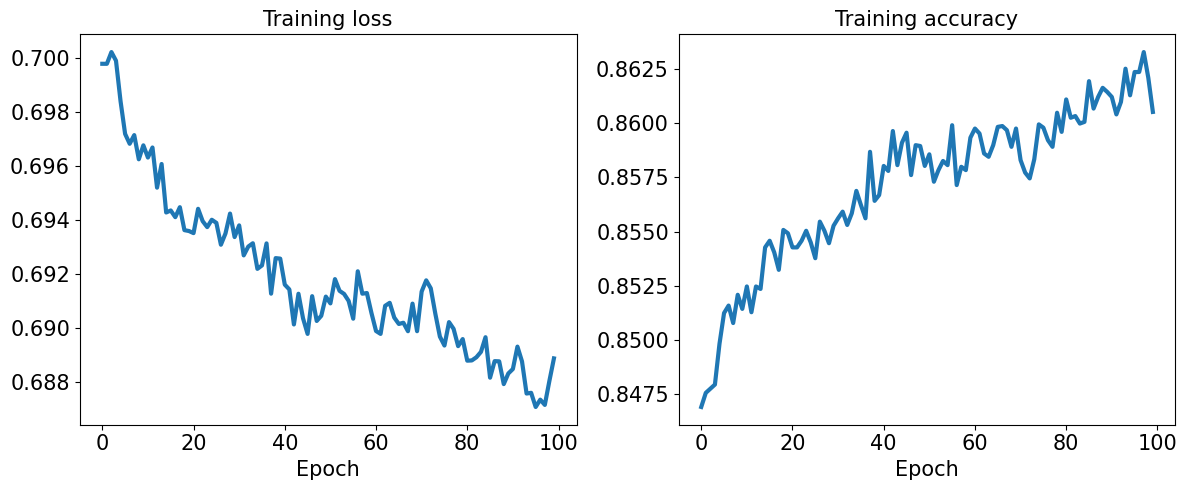

In [15]:
# Tests a second training run by raising the learning rate to 0.01, repeating 100 epochs, and plotting metrics to compare with the first model.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        y_batch = y_batch.squeeze()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()

    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
plt.show()

In [17]:
# Uses the trained model that performed best, normalizes the validation features with training statistics, and converts them to tensors for prediction.
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm.values).float()

# Runs the network without gradient tracking, extracts the predicted class for every record, and prints a quick sample.
with torch.no_grad():
    pred_test = model(X_test_norm)
    predicted_classes = torch.argmax(pred_test, dim=1)

print(predicted_classes[:10])

# Maps the predicted classes back to labels, converts them into the required 1 and -1 format, and saves a CSV for submission.
income_classes = le_dict[target_col].classes_
predicted_labels = income_classes[predicted_classes.numpy()]
validation_outputs = np.where(predicted_labels == '>50K', 1, -1)

validation_output_df = pd.DataFrame({'prediction': validation_outputs})
validation_output_path = 'validation_predictions.csv'
validation_output_df.to_csv(validation_output_path, index=False)
validation_output_path


tensor([0, 0, 1, 0, 0, 1, 1, 0, 0, 1])


'validation_predictions.csv'